In [1]:
!pip install torch torchvision matplotlib scikit-learn

Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 351kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.56MB/s]



Розмір датасету зменшено у 1 разів
Кількість навчальних зображень: 60000

Навчання Net_Linear
Epoch: 1 Loss: 0.34979651329804584
Epoch: 2 Loss: 0.1634237097957527
Net_Linear accuracy: 0.9575
Net_Linear time: 21.45004677772522

Навчання Net_Conv
Epoch: 1 Loss: 0.1866793355006955
Epoch: 2 Loss: 0.05202861600279955
Net_Conv accuracy: 0.9826
Net_Conv time: 171.25803327560425

Розмір датасету зменшено у 2 разів
Кількість навчальних зображень: 30000

Навчання Net_Linear
Epoch: 1 Loss: 0.45898767257295947
Epoch: 2 Loss: 0.21265871150852012
Net_Linear accuracy: 0.9453
Net_Linear time: 9.539056062698364

Навчання Net_Conv
Epoch: 1 Loss: 0.3186344269996704
Epoch: 2 Loss: 0.07894920967995867
Net_Conv accuracy: 0.9808
Net_Conv time: 83.23452615737915

Розмір датасету зменшено у 4 разів
Кількість навчальних зображень: 15000

Навчання Net_Linear
Epoch: 1 Loss: 0.6300142586548277
Epoch: 2 Loss: 0.28362664193549053
Net_Linear accuracy: 0.918
Net_Linear time: 4.896488904953003

Навчання Net_Conv
Epoch

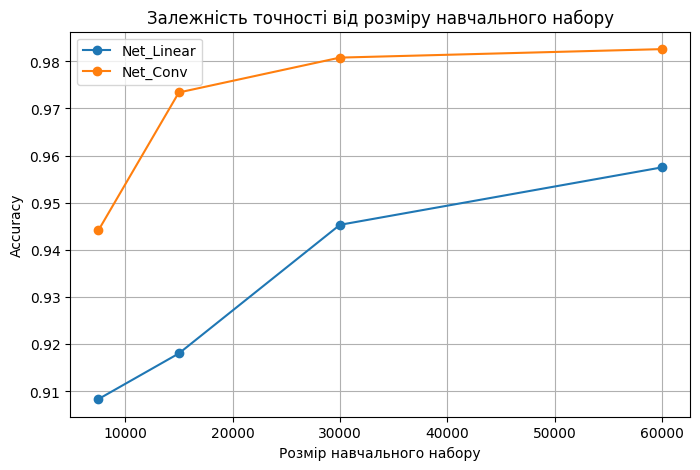

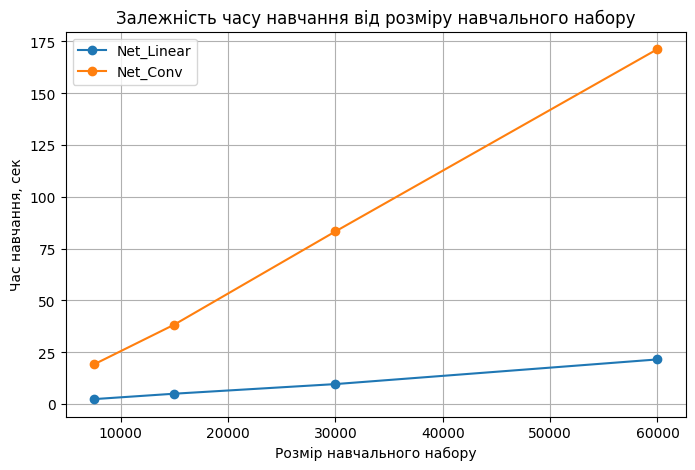

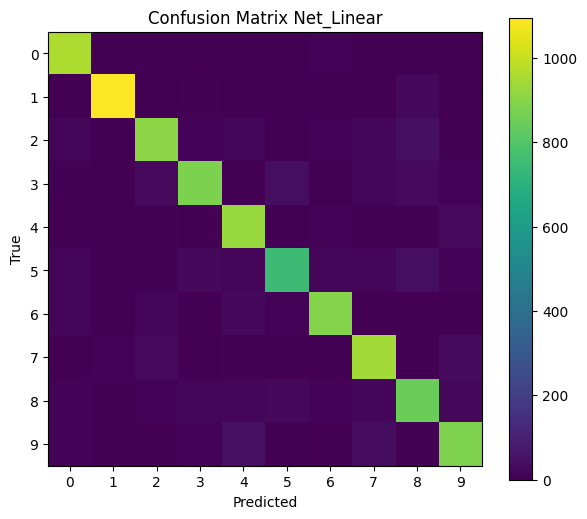

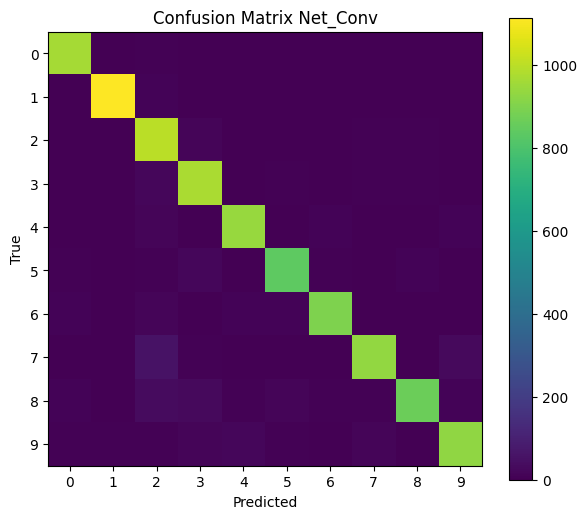

README.txt створено


In [2]:
import time
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix


# ---------- Налаштування ----------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 64
epochs = 2


# ---------- Підготовка даних ----------

transform = transforms.ToTensor()

trainset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

testloader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False
)


# ---------- Моделі ----------

class Net_Linear(nn.Module):
    def __init__(self):
        super(Net_Linear, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class Net_Conv(nn.Module):
    def __init__(self):
        super(Net_Conv, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 14 * 14)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# ---------- Функція для створення зменшеного датасету ----------

def make_subset(dataset, divider):
    size = len(dataset) // divider
    indexes = list(range(size))
    return Subset(dataset, indexes)


# ---------- Навчання ----------

def train_model(model, trainloader):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    for epoch in range(epochs):
        running_loss = 0

        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print("Epoch:", epoch + 1, "Loss:", running_loss / len(trainloader))

    end_time = time.time()
    train_time = end_time - start_time

    return model, train_time


# ---------- Перевірка точності ----------

def test_model(model, testloader):
    model.eval()

    correct = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    accuracy = correct / total

    return accuracy, y_true, y_pred


# ---------- Матриця плутанини ----------

def show_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(10)
    plt.xticks(tick_marks, range(10))
    plt.yticks(tick_marks, range(10))

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return cm


# ---------- Основний експеримент ----------

dividers = [1, 2, 4, 8]

results = []

last_linear_true = None
last_linear_pred = None
last_conv_true = None
last_conv_pred = None

for divider in dividers:
    print("\n===================================")
    print("Розмір датасету зменшено у", divider, "разів")
    print("===================================")

    train_subset = make_subset(trainset, divider)

    trainloader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True
    )

    dataset_size = len(train_subset)
    print("Кількість навчальних зображень:", dataset_size)

    # Linear model
    print("\nНавчання Net_Linear")
    linear_model = Net_Linear()
    linear_model, linear_time = train_model(linear_model, trainloader)
    linear_acc, linear_true, linear_pred = test_model(linear_model, testloader)

    print("Net_Linear accuracy:", linear_acc)
    print("Net_Linear time:", linear_time)

    results.append({
        "model": "Net_Linear",
        "divider": divider,
        "dataset_size": dataset_size,
        "accuracy": linear_acc,
        "time": linear_time
    })

    # Conv model
    print("\nНавчання Net_Conv")
    conv_model = Net_Conv()
    conv_model, conv_time = train_model(conv_model, trainloader)
    conv_acc, conv_true, conv_pred = test_model(conv_model, testloader)

    print("Net_Conv accuracy:", conv_acc)
    print("Net_Conv time:", conv_time)

    results.append({
        "model": "Net_Conv",
        "divider": divider,
        "dataset_size": dataset_size,
        "accuracy": conv_acc,
        "time": conv_time
    })

    last_linear_true = linear_true
    last_linear_pred = linear_pred
    last_conv_true = conv_true
    last_conv_pred = conv_pred


# ---------- Таблиця результатів ----------

print("\nРезультати:")

for item in results:
    print(item)


# ---------- Графік точності ----------

linear_sizes = []
linear_accs = []
conv_sizes = []
conv_accs = []

for item in results:
    if item["model"] == "Net_Linear":
        linear_sizes.append(item["dataset_size"])
        linear_accs.append(item["accuracy"])
    else:
        conv_sizes.append(item["dataset_size"])
        conv_accs.append(item["accuracy"])

plt.figure(figsize=(8, 5))
plt.plot(linear_sizes, linear_accs, marker="o", label="Net_Linear")
plt.plot(conv_sizes, conv_accs, marker="o", label="Net_Conv")
plt.title("Залежність точності від розміру навчального набору")
plt.xlabel("Розмір навчального набору")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


# ---------- Графік часу навчання ----------

linear_times = []
conv_times = []

for item in results:
    if item["model"] == "Net_Linear":
        linear_times.append(item["time"])
    else:
        conv_times.append(item["time"])

plt.figure(figsize=(8, 5))
plt.plot(linear_sizes, linear_times, marker="o", label="Net_Linear")
plt.plot(conv_sizes, conv_times, marker="o", label="Net_Conv")
plt.title("Залежність часу навчання від розміру навчального набору")
plt.xlabel("Розмір навчального набору")
plt.ylabel("Час навчання, сек")
plt.legend()
plt.grid()
plt.show()


# ---------- Матриці плутанини для останнього експерименту ----------

show_confusion_matrix(
    last_linear_true,
    last_linear_pred,
    "Confusion Matrix Net_Linear"
)

show_confusion_matrix(
    last_conv_true,
    last_conv_pred,
    "Confusion Matrix Net_Conv"
)


# ---------- Збереження результатів у README ----------

with open("README.txt", "w", encoding="utf-8") as file:
    file.write("Практичне заняття 9. PyTorch MNIST\n\n")

    file.write("Мета роботи:\n")
    file.write("Дослідити, як розмір навчального набору MNIST впливає на точність та час навчання моделей Net_Linear і Net_Conv.\n\n")

    file.write("Результати експериментів:\n")
    for item in results:
        file.write(
            item["model"] +
            ", divider=" + str(item["divider"]) +
            ", dataset_size=" + str(item["dataset_size"]) +
            ", accuracy=" + str(round(item["accuracy"], 4)) +
            ", time=" + str(round(item["time"], 2)) + " sec\n"
        )

    file.write("\nВисновок:\n")
    file.write("При зменшенні розміру навчального набору точність моделей зазвичай зменшується.\n")
    file.write("Модель Net_Conv зазвичай показує кращу точність, бо вона краще працює із зображеннями.\n")
    file.write("Модель Net_Linear навчається швидше, але може давати нижчу точність.\n")
    file.write("Чим більший навчальний набір, тим більше часу потрібно для навчання.\n")
    file.write("Основний компроміс полягає в тому, що більший датасет дає кращу точність, але потребує більше часу.\n")
    file.write("Для покращення точності на малих наборах можна збільшити кількість епох, використати аугментацію даних або покращити архітектуру моделі.\n")

print("README.txt створено")

Висновок

У практичній роботі було досліджено вплив розміру навчального набору MNIST на точність і час навчання двох моделей: Net_Linear та Net_Conv.

Навчальний набір було зменшено у 2, 4 та 8 разів за допомогою torch.utils.data.Subset. Для кожного розміру набору були навчені обидві моделі. Після навчання вимірювався час навчання та точність на тестовому наборі.

За результатами експерименту можна зробити висновок, що при зменшенні кількості навчальних даних точність моделей зазвичай зменшується. Модель Net_Conv показує кращу точність, оскільки вона краще підходить для обробки зображень. Модель Net_Linear навчається швидше, але її точність зазвичай нижча.

Також було побудовано графіки залежності точності та часу навчання від розміру навчального набору. Матриця плутанини показала, які цифри моделі плутають найчастіше. Найчастіше моделі можуть плутати схожі цифри, наприклад 4 і 9, 3 і 5 або 7 і 9.

Основний компроміс полягає в тому, що більший навчальний набір дає кращу точність, але потребує більше часу для навчання.